In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv('auto-mpg.data', delim_whitespace=True, names=column_names)

# Clean horsepower: replace '?' with NaN and convert to float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

# Map 'origin' to categories
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Asia'})

# One-hot encode origin
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

# Select features (exclude mpg and car_name)
X = df.drop(['mpg', 'car_name'], axis=1)
y = df['mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Coefficients (impact of each feature)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

MAE: 2.466228550681242
MSE: 10.207182208694325
R² Score: 0.7976095117999201
               Coefficient
cylinders        -0.376622
displacement      0.019035
horsepower       -0.021702
weight           -0.006340
acceleration      0.037491
model_year        0.796142
origin_Europe    -0.201321
origin_USA       -3.244727


C:\Users\meyus\AppData\Local\Temp\ipykernel_16260\586113491.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('auto-mpg.data', delim_whitespace=True, names=column_names)


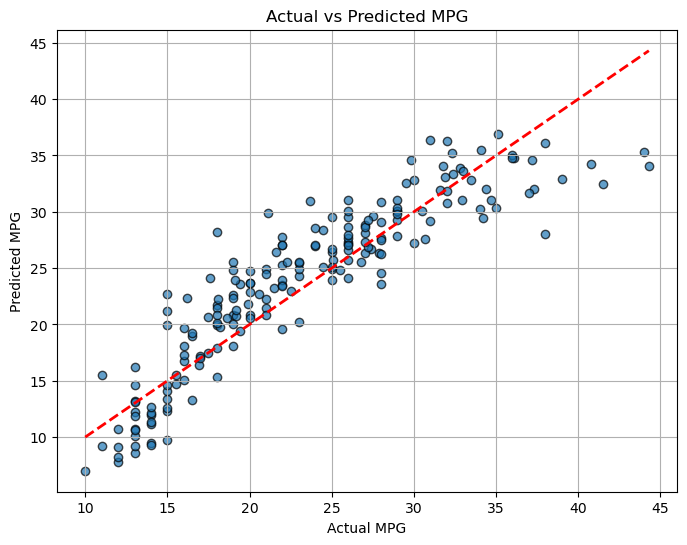

In [2]:
import matplotlib.pyplot as plt

# Scatter plot: Actual vs Predicted MPG
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.grid(True)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features & target
X = df_clean.drop(columns=['mpg'])
y = df_clean['mpg']

# Encode categoricals automatically
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 5.820961265822782
R² Score: 0.8859542564694617
